In [1]:
!pip install pandas numpy scikit-learn requests tldextract xgboost scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 2.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import requests
import re
import tldextract
import matplotlib.pyplot as plt

from urllib.parse import urlparse
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier

In [3]:
def load_blacklist():
    url = "https://openphish.com/feed.txt"
    response = requests.get(url)
    return set(response.text.splitlines())

blacklist = load_blacklist()
print("✅ Blacklist Loaded:", len(blacklist))

✅ Blacklist Loaded: 300


In [4]:
def check_blacklist(url):
    return "PHISHING" if url in blacklist else "NOT_FOUND"

In [6]:
df1 = pd.read_csv('/content/phishing_site_urls.csv')
df1['Label'] = df1['Label'].map({'bad':1, 'good':0})

df2 = pd.read_csv('/content/malicious_phish.csv')
df2 = df2.rename(columns={'url':'URL', 'type':'Label'})

# Binary conversion
df2['Label'] = df2['Label'].apply(lambda x: 0 if x == 'benign' else 1)

# Merge
df = pd.concat([df1[['URL','Label']], df2[['URL','Label']]], ignore_index=True)

# OPTIONAL: Reduce size if needed (avoid crash)
df = df.sample(500000, random_state=42)

print("✅ Dataset Ready:", df.shape)

✅ Dataset Ready: (500000, 2)


In [7]:
def extract_features(url):
    parsed = urlparse(url)
    ext = tldextract.extract(url)

    suspicious_words = ['login','secure','bank','verify','update']

    return [
        len(url),
        len(ext.domain),
        url.count('.'),
        url.count('-'),
        url.count('@'),
        url.count('?'),
        url.count('='),
        sum(c.isdigit() for c in url),
        1 if parsed.scheme == 'https' else 0,
        len(parsed.path),
        len(parsed.query),
        len(ext.subdomain.split('.')) if ext.subdomain else 0,
        1 if any(word in url.lower() for word in suspicious_words) else 0,
        1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0
    ]

In [8]:
# Manual features
X_features = np.array([extract_features(url) for url in df['URL']])
X_features = csr_matrix(X_features)

# TF-IDF (NO .toarray)
tfidf = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf.fit_transform(df['URL'])

# Combine safely
X = hstack([X_features, X_tfidf])

y = df['Label']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='logloss'
    )
}

results = {}
best_model = None
best_accuracy = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    results[name] = acc
    print(f"✅ {name}: {acc:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_preds = preds

print("\n🏆 Best Model:", best_model)

✅ Random Forest: 0.8826


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Logistic Regression: 0.8534
✅ Decision Tree: 0.8762
✅ KNN: 0.8580
✅ Gradient Boosting: 0.8430
✅ XGBoost: 0.8720

🏆 Best Model: RandomForestClassifier(class_weight='balanced')


In [11]:
print(classification_report(y_test, best_preds))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91     68448
           1       0.80      0.84      0.82     31552

    accuracy                           0.88    100000
   macro avg       0.86      0.87      0.87    100000
weighted avg       0.88      0.88      0.88    100000



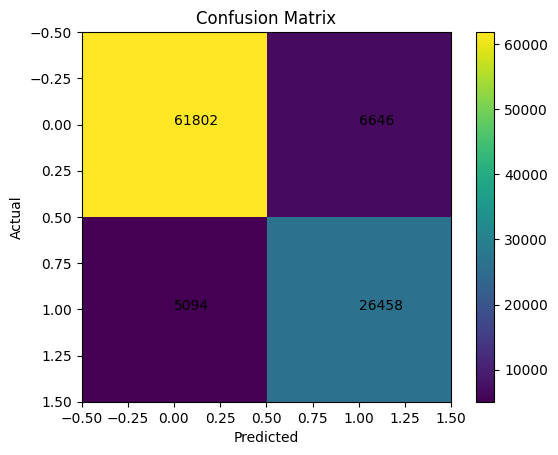

In [12]:
cm = confusion_matrix(y_test, best_preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j])

plt.colorbar()
plt.show()

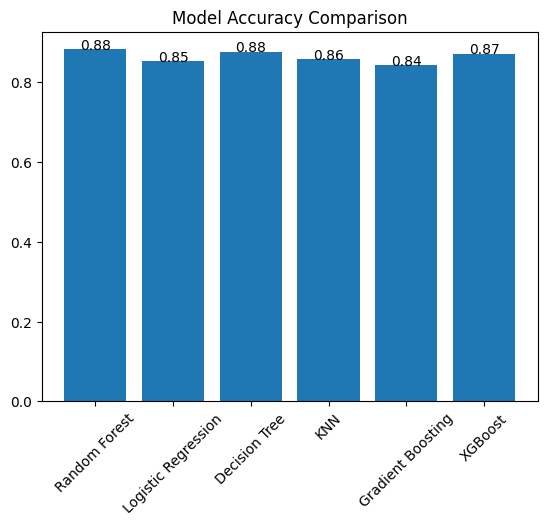

In [13]:
plt.figure()

names = list(results.keys())
values = list(results.values())

plt.bar(names, values)
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

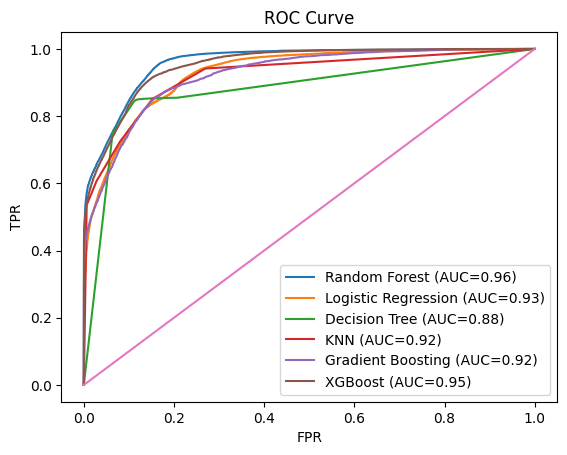

In [14]:
plt.figure()

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1])
plt.legend()
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [15]:
def predict_url_ml(url):

    feat = np.array(extract_features(url)).reshape(1, -1)
    feat = csr_matrix(feat)

    tfidf_feat = tfidf.transform([url])

    final_input = hstack([feat, tfidf_feat])

    pred = best_model.predict(final_input)[0]

    return "PHISHING" if pred == 1 else "LEGITIMATE"

In [16]:
def is_valid_url(url):
    pattern = re.compile(
        r'^(https?:\/\/)?'
        r'([a-zA-Z0-9\-]+\.)+'
        r'[a-zA-Z]{2,}'
    )
    return re.match(pattern, url) is not None

In [17]:
def final_detect(url):

    print("\n🔍 Checking:", url)

    if not is_valid_url(url):
        print("❌ Invalid URL")
        return

    if check_blacklist(url) == "PHISHING":
        print("🚨 PHISHING (Blacklist)")
        return

    print("✅ Not in Blacklist → ML Model")

    result = predict_url_ml(url)

    if result == "PHISHING":
        print("🚨 PHISHING (ML)")
    else:
        print("✅ LEGITIMATE")

In [18]:
pip install joblib

In [19]:
import joblib

# Save model
joblib.dump(best_model, "best_model.pkl")

# Save TF-IDF
joblib.dump(tfidf, "tfidf.pkl")

print("✅ Model & TF-IDF Saved Successfully")

✅ Model & TF-IDF Saved Successfully


In [20]:
from google.colab import files

files.download("best_model.pkl")
files.download("tfidf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
while True:
    url = input("\n🌐 Enter URL (or 'exit'): ")

    if url.lower() == 'exit':
        break

    final_detect(url)


🌐 Enter URL (or 'exit'): mp3raid.com/music/krizz_kaliko.html

🔍 Checking: mp3raid.com/music/krizz_kaliko.html
✅ Not in Blacklist → ML Model
✅ LEGITIMATE

🌐 Enter URL (or 'exit'): http://www.pashminaonline.com/pure-pashminas

🔍 Checking: http://www.pashminaonline.com/pure-pashminas
✅ Not in Blacklist → ML Model
🚨 PHISHING (ML)

🌐 Enter URL (or 'exit'): http://virus-control.com/s/63BZGFSVBWSFCDX7Y9/584dd8/90eab167-7429-489f-99f6-ce86e8d0d81a

🔍 Checking: http://virus-control.com/s/63BZGFSVBWSFCDX7Y9/584dd8/90eab167-7429-489f-99f6-ce86e8d0d81a
🚨 PHISHING (Blacklist)

🌐 Enter URL (or 'exit'): jfgshgfvuwshtgoksw

🔍 Checking: jfgshgfvuwshtgoksw
❌ Invalid URL

🌐 Enter URL (or 'exit'): exit
